# CylinderFlow assignment: deterministic prediction vs conditional flow matching

In this assignment you will model the future velocity field of a two-dimensional flow around a cylinder on an **unstructured, nonuniform triangular mesh**.

You will build two predictors using the **same supplied data**:

1. a **deterministic predictor** trained as a point predictor; and
2. a **conditional flow-matching predictor** that represents a distribution of possible future velocity fields.

The neural-network architecture is **not prescribed**. Your model should be able to use the information supplied by the mesh and the current flow state.

This notebook provides the problem specification, data loading, dataset class, data inspection, and the final evaluation code. Model architecture, optimization, training, and the numerical details of flow-matching sampling are your task.


## 1. What is in the dataset?

The cylinder-flow dataset is based on the MeshGraphNets benchmark introduced by Pfaff et al. in [*Learning Mesh-Based Simulation with Graph Networks*](https://arxiv.org/abs/2010.03409) (ICLR 2021). The data consist of multiple independent **trajectories** of two-dimensional flow around a cylinder.

The assignment file is intended to contain:

- **500 training trajectories**;
- **20 validation trajectories**;
- **20 held-out test trajectories**.

Each trajectory contains:

- **600 time states** separated by $\Delta t=0.01\,\mathrm{s}$, corresponding to times $0,0.01,\ldots,5.99\,\mathrm{s}$;
- one **static 2D triangular mesh** that is reused for all 600 states in that trajectory;
- a 2D velocity vector $(u_x,u_y)$ at every mesh node and every time state;
- a node-type label describing whether a node is an interior node, inflow node, outflow node, or wall boundary node.

### Important mesh properties

The mesh is **unstructured and spatially nonuniform**. It is not a Cartesian image grid, so the velocity field should not be reshaped into a rectangular image.

The number of nodes is **not identical across trajectories**. In the supplied training data, trajectories have roughly 600 nodes on average (the current training set spans approximately 552--898 nodes). Triangle connectivity also varies across trajectories.

Within a single trajectory, however, the mesh is fixed in time: only the velocity field changes.

The loading cells below verify the exact split sizes and mesh statistics stored in your copy of the data file.


### Array structure for one trajectory

For a trajectory with \(T\) time states, \(N\) mesh nodes, and \(M\) triangles:

| key | shape | meaning |
|---|---:|---|
| `mesh_pos` | `(N, 2)` | node coordinates $(x,y)$ |
| `cells` | `(M, 3)` | the three node indices of every triangular cell |
| `node_type` | `(N,)` | integer boundary/interior label for each node |
| `velocity` | `(T, N, 2)` | velocity components $(u_x,u_y)$ |

The node labels used in this assignment are:

- `0`: interior / normal node
- `4`: inflow node
- `5`: outflow node
- `6`: wall boundary node

The **dynamic nodes** for the prediction loss are interior and outflow nodes (`0` and `5`).

In the supplied dataset, inflow (`4`) and wall (`6`) velocities are prescribed boundary values and are constant in time. They therefore do not need to be learned as evolving state variables. During autoregressive rollout, restore these known boundary values after every prediction step.


In [2]:
!pip -q install h5py tqdm

In [3]:
from pathlib import Path
import math
import random

import h5py
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [4]:
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU: Tesla T4


## 2. Download and load the supplied data file

The code below will download and place the supplied HDF5 file next to this notebook.

The HDF5 file is organized as

```text
/train/traj_0000/...
/train/traj_0001/...
/valid/traj_0000/...
/test/traj_0000/...
```

Each trajectory group contains the four arrays described above.

In [6]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# !pip install -q gdown
# !gdown "1Gqz9b4hfoDaOYvupbHlf1pl_48AP-oZ4" -O "/content/drive/MyDrive/ML for science/cylinderflow_assignment.h5"

In [7]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
!ls "/content/drive/MyDrive/ML for science/"

Mounted at /content/drive
 Assignment_2_part_1.ipynb	        cylinderflow_assignment.h5
 Assignment_2_Part2_Core_Framework.md  'Interview preparation.gdoc'
 best_deterministic.pt		        part-1.docx
 best_flow_matching.pt


In [8]:
from pathlib import Path
import shutil
import h5py

DRIVE_DATA_PATH = Path(
    "/content/drive/MyDrive/ML for science/cylinderflow_assignment.h5"
)

DATA_PATH = Path(
    "/content/cylinderflow_assignment.h5"
)

if DATA_PATH.exists() and not h5py.is_hdf5(DATA_PATH):
    DATA_PATH.unlink()

if not DATA_PATH.exists():
    print("Copying dataset to local Colab storage...")
    shutil.copy2(
        DRIVE_DATA_PATH,
        DATA_PATH
    )

print("Dataset:", DATA_PATH)
print("Valid HDF5:", h5py.is_hdf5(DATA_PATH))
print(
    "File size:",
    f"{DATA_PATH.stat().st_size / 1024**2:.1f} MB"
)

Copying dataset to local Colab storage...
Dataset: /content/cylinderflow_assignment.h5
Valid HDF5: True
File size: 747.9 MB


In [ ]:
# # ============================================================
# # Download dataset
# # ============================================================
# # DATA_PATH = Path("/content/drive/MyDrive/ML for science/cylinderflow_assignment.h5")

# if not DATA_PATH.exists():
#     !pip -q install gdown

#     import gdown

#     DATA_URL = "1Gqz9b4hfoDaOYvupbHlf1pl_48AP-oZ4"


#     print("Downloading dataset...")

#     gdown.download(
#         id=DATA_URL,
#         output=str(DATA_PATH),
#         quiet=False,
#     )

#     print(
#         "Download complete:",
#         DATA_PATH,
#     )

# else:
#     print(
#         "Dataset already available:",
#         DATA_PATH,
#     )

In [9]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Change DATA_PATH to the supplied dataset file."
    )

with h5py.File(DATA_PATH, "r") as f:
    DT = float(f.attrs["dt"])
    HORIZON_STEPS = int(f.attrs["prediction_horizon_steps"])
    PREDICTION_DT = float(f.attrs["prediction_horizon_seconds"])

    print("Dataset:", f.attrs.get("dataset_name", "CylinderFlow"))
    print(f"Stored time step: {DT:.3f} s")
    print(f"Prediction horizon: {HORIZON_STEPS} states = {PREDICTION_DT:.1f} s")

    for split in ["train", "valid", "test"]:
        ids = sorted(f[split].keys())
        node_counts = np.array([f[split][tid]["mesh_pos"].shape[0] for tid in ids])
        tri_counts = np.array([f[split][tid]["cells"].shape[0] for tid in ids])
        n_states = np.array([f[split][tid]["velocity"].shape[0] for tid in ids])

        print(f"\n{split.upper()}")
        print("  trajectories:", len(ids))
        print("  states/trajectory:", sorted(set(n_states.tolist())))
        print(
            "  nodes: min / mean / max =",
            int(node_counts.min()),
            f"{node_counts.mean():.1f}",
            int(node_counts.max()),
        )

Dataset: CylinderFlow assignment dataset
Stored time step: 0.010 s
Prediction horizon: 100 states = 1.0 s

TRAIN
  trajectories: 500
  states/trajectory: [600]
  nodes: min / mean / max = 552 601.1 898

VALID
  trajectories: 20
  states/trajectory: [600]
  nodes: min / mean / max = 561 593.0 633

TEST
  trajectories: 20
  states/trajectory: [600]
  nodes: min / mean / max = 565 586.2 633


### Trajectories versus training pairs

The learning task uses a **direct 1-second prediction horizon**. Since the stored time spacing is $0.01\,\mathrm{s}$, the target for state index $t$ is state index $t+100$.

Let $x_t$ denote the **full flow state at physical time $t$ seconds**. The training pairs are sliding 1-second pairs such as

$
(x_{0.00},x_{1.00}),\quad
(x_{0.01},x_{1.01}),\quad
(x_{0.02},x_{1.02}),\quad \ldots
$

and later in the same trajectory,

$
(x_{1.00},x_{2.00}),\quad
(x_{1.05},x_{2.05}),\quad \ldots,\quad
(x_{4.99},x_{5.99}).
$

The important point is:

> **1 second is the separation between the input and target, not the spacing between consecutive training examples.**

A trajectory with 600 stored states provides

$
600-100=500
$

possible 1-second input/target pairs. Thus 500 training trajectories correspond to $250{,}000$ possible pairs, but they still come from only 500 independent trajectories.


## 3. Dataset class

The class below returns raw physical quantities and makes no assumption about your model architecture.

Because different trajectories can have different numbers of nodes, a conventional tensor batch cannot in general stack examples from different meshes. The provided `variable_mesh_collate` therefore returns a Python list when `batch_size > 1`. You may process samples individually, group compatible samples yourself, or implement another batching strategy.


In [10]:
NORMAL = 0
INFLOW = 4
OUTFLOW = 5
WALL_BOUNDARY = 6


def dynamic_node_mask(node_type):
    """Nodes whose velocity is predicted/evaluated dynamically."""
    return (node_type == NORMAL) | (node_type == OUTFLOW)


class CylinderFlowPairDataset(Dataset):
    """
    Direct-horizon input/target pairs from a variable-size triangular-mesh dataset.

    One item contains the static mesh plus
        velocity_t       = u(t)
        velocity_target  = u(t + 1 s)
        delta_velocity   = velocity_target - velocity_t
    """

    def __init__(self, h5_path, split="train"):
        self.h5_path = str(h5_path)
        self.split = split
        self._h5 = None
        self._static_cache = {}

        with h5py.File(self.h5_path, "r") as f:
            if split not in f:
                raise KeyError(f"Unknown split {split!r}")

            self.dt = float(f.attrs["dt"])
            self.horizon_steps = int(f.attrs["prediction_horizon_steps"])
            self.prediction_dt = float(f.attrs["prediction_horizon_seconds"])
            self.traj_ids = sorted(f[split].keys())

            self.index = []
            for traj_id in self.traj_ids:
                T = int(f[split][traj_id]["velocity"].shape[0])
                n_valid = T - self.horizon_steps
                self.index.extend((traj_id, t) for t in range(n_valid))

    def _file(self):
        # Each DataLoader worker gets its own lazily opened handle.
        if self._h5 is None:
            self._h5 = h5py.File(self.h5_path, "r")
        return self._h5

    def __getstate__(self):
        state = self.__dict__.copy()
        state["_h5"] = None
        state["_static_cache"] = {}
        return state

    def __len__(self):
        return len(self.index)

    def _static(self, traj_id):
        if traj_id not in self._static_cache:
            g = self._file()[self.split][traj_id]
            self._static_cache[traj_id] = {
                "mesh_pos": torch.from_numpy(g["mesh_pos"][:]).float(),
                "cells": torch.from_numpy(g["cells"][:].astype(np.int64)).long(),
                "node_type": torch.from_numpy(g["node_type"][:].astype(np.int64)).long(),
            }
        return self._static_cache[traj_id]

    def __getitem__(self, idx):
        traj_id, t = self.index[idx]
        g = self._file()[self.split][traj_id]
        static = self._static(traj_id)

        u0 = torch.from_numpy(g["velocity"][t]).float()
        u1 = torch.from_numpy(g["velocity"][t + self.horizon_steps]).float()

        return {
            "trajectory_id": traj_id,
            "time_index": t,
            "time_s": t * self.dt,
            "target_time_index": t + self.horizon_steps,
            "target_time_s": (t + self.horizon_steps) * self.dt,
            "mesh_pos": static["mesh_pos"],
            "cells": static["cells"],
            "node_type": static["node_type"],
            "dynamic_mask": dynamic_node_mask(static["node_type"]),
            "velocity_t": u0,
            "velocity_target": u1,
            "delta_velocity": u1 - u0,
        }

    def close(self):
        if self._h5 is not None:
            self._h5.close()
            self._h5 = None


def variable_mesh_collate(batch):
    # Mesh sizes vary, so do not torch.stack different trajectories automatically.
    return batch


train_dataset = CylinderFlowPairDataset(DATA_PATH, "train")
valid_dataset = CylinderFlowPairDataset(DATA_PATH, "valid")
test_dataset = CylinderFlowPairDataset(DATA_PATH, "test")

print("Training pairs:", len(train_dataset))
print("Validation pairs:", len(valid_dataset))
print("Test pairs:", len(test_dataset))

Training pairs: 250000
Validation pairs: 10000
Test pairs: 10000


### Concrete examples of the 1-second pairs

The following cell prints several pairs from the first training trajectory. It is included to make the sliding horizon explicit. For example, a pair beginning at $1.05\,\mathrm{s}$ has its target at $2.05\,\mathrm{s}$, not at the next stored state $1.06\,\mathrm{s}$.


In [11]:
# Show several explicit pairs from the first training trajectory.
first_traj_id = train_dataset.traj_ids[0]

example_start_steps = [
    0,      # 0.00 -> 1.00 s
    1,      # 0.01 -> 1.01 s
    100,    # 1.00 -> 2.00 s
    105,    # 1.05 -> 2.05 s
    499,    # 4.99 -> 5.99 s
]

print("Examples from", first_traj_id)

for t_idx in example_start_steps:
    dataset_idx = train_dataset.index.index((first_traj_id, t_idx))
    item = train_dataset[dataset_idx]

    print(
        f"x_{item['time_s']:.2f}  ->  "
        f"x_{item['target_time_s']:.2f}  "
        f"(indices {item['time_index']} -> {item['target_time_index']})"
    )


Examples from traj_0000
x_0.00  ->  x_1.00  (indices 0 -> 100)
x_0.01  ->  x_1.01  (indices 1 -> 101)
x_1.00  ->  x_2.00  (indices 100 -> 200)
x_1.05  ->  x_2.05  (indices 105 -> 205)
x_4.99  ->  x_5.99  (indices 499 -> 599)


In [12]:
# Inspect one direct 1-second pair.
example = train_dataset[0]

for key in [
    "mesh_pos",
    "cells",
    "node_type",
    "velocity_t",
    "velocity_target",
    "delta_velocity",
]:
    print(f"{key:18s}", tuple(example[key].shape))

print("input time:", example["time_s"], "s")
print("target time:", example["target_time_s"], "s")
print("dynamic nodes:", int(example["dynamic_mask"].sum()), "/", len(example["node_type"]))


mesh_pos           (596, 2)
cells              (958, 3)
node_type          (596,)
velocity_t         (596, 2)
velocity_target    (596, 2)
delta_velocity     (596, 2)
input time: 0.0 s
target time: 1.0 s
dynamic nodes: 379 / 596


## 4. Visualize the mesh and one 1-second pair

The left panel shows the triangular connectivity. The other panels show velocity magnitude
$
|\mathbf u|=\sqrt{u_x^2+u_y^2}
$
at the input and target times.

Notice that the mesh spacing is nonuniform and the geometry is represented directly by node coordinates and triangle connectivity.


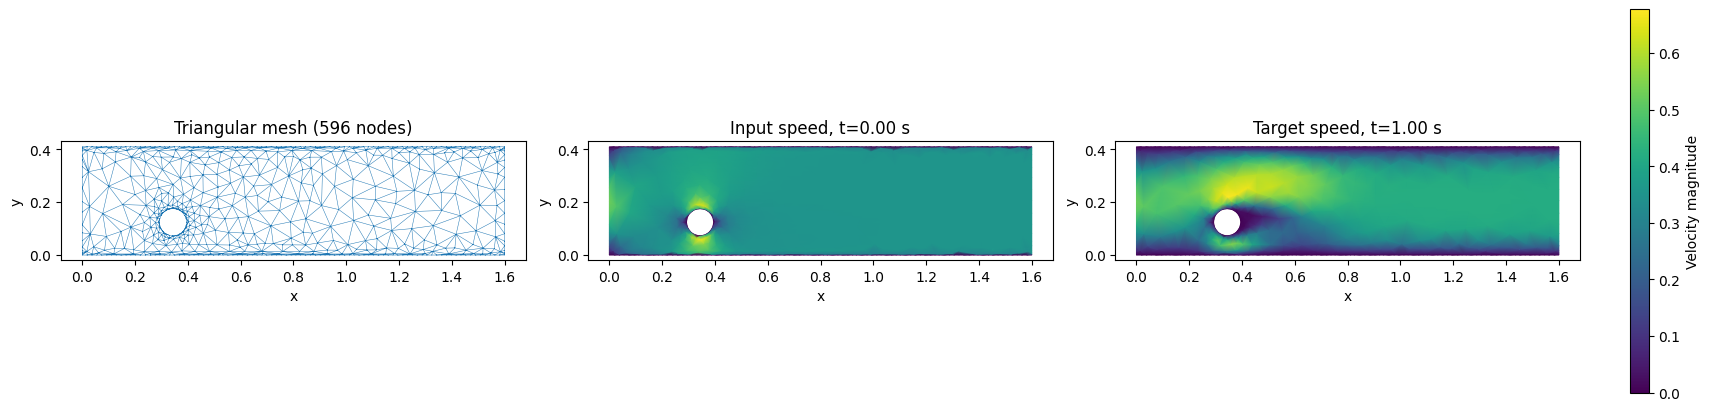

In [13]:
pos = example["mesh_pos"].numpy()
cells = example["cells"].numpy()

speed0 = torch.linalg.vector_norm(example["velocity_t"], dim=-1).numpy()
speed1 = torch.linalg.vector_norm(example["velocity_target"], dim=-1).numpy()

vmin = min(float(speed0.min()), float(speed1.min()))
vmax = max(float(speed0.max()), float(speed1.max()))

fig, axes = plt.subplots(1, 3, figsize=(17, 4), constrained_layout=True)

axes[0].triplot(pos[:, 0], pos[:, 1], cells, linewidth=0.35)
axes[0].set_title(f"Triangular mesh ({len(pos)} nodes)")

m0 = axes[1].tripcolor(
    pos[:, 0], pos[:, 1], cells, speed0,
    shading="gouraud", vmin=vmin, vmax=vmax,
)
axes[1].set_title(f"Input speed, t={example['time_s']:.2f} s")

m1 = axes[2].tripcolor(
    pos[:, 0], pos[:, 1], cells, speed1,
    shading="gouraud", vmin=vmin, vmax=vmax,
)
axes[2].set_title(f"Target speed, t={example['target_time_s']:.2f} s")

for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.colorbar(m1, ax=axes[1:], label="Velocity magnitude")
plt.show()

## 5. Prediction task

For every training example you are given the current state
$
\mathcal C_t=
\{\mathbf u_t,\;\text{mesh positions},\;\text{triangle connectivity},\;\text{node types}\}
$
and the target state one physical second later,
$
\mathbf u_{t+1\mathrm{s}}.
$
It is convenient to model the 1-second velocity increment
$
\Delta\mathbf u_t=
\mathbf u_{t+1\mathrm{s}}-\mathbf u_t.
$

### Deterministic model

You should construct a deterministic model that predicts one increment (or equivalently one future state) from the conditioning state. A standard deterministic baseline minimizes mean-squared error on the dynamic nodes.

### Conditional flow matching

You should construct a conditional flow-matching model for the distribution
$
p(\Delta\mathbf u_t\mid\mathcal C_t).
$
For conditional flow matching, a common training construction is:
$
\epsilon\sim\mathcal N(0,I),
\qquad
\tau\sim U[0,1],
$

$
z_\tau=(1-\tau)\epsilon+\tau\widetilde{\Delta\mathbf u}_t,
$

with target vector field

$
v^*=
\widetilde{\Delta\mathbf u}_t-\epsilon.
$

A sample is generated by integrating the learned ODE from $\tau=0$ to $1$, starting from fresh Gaussian noise.

Only **dynamic nodes** (`NORMAL` and `OUTFLOW`) should contribute to the prediction loss. During rollout, known inflow and wall values should remain fixed.

### What is not prescribed

You choose the model architecture, data normalization, feature representation, optimizer, learning-rate schedule, and the flow-matching sampler. Your design must support variable-size, nonuniform meshes.


## 6. Your model and training code

Implement your models and training procedure below.

Use only the **training split** for fitting model parameters and training statistics. Use the **validation split** for model selection. Do not tune on the test split.

For the final evaluation code later in this notebook, your implementation only needs to provide two small adapter functions that produce a **full next velocity field** after one 1-second model step. These adapter functions must return velocities in physical, unnormalized units.


In [14]:
# ============================================================
# TODO: your deterministic model, flow-matching model, training,
# validation, checkpointing, and inference utilities go here.
# ============================================================

# 6. Models, training, validation, checkpointing
import copy
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, RandomSampler

NUM_NODE_TYPES = 7
USE_AMP = DEVICE.type == "cuda"          # mixed precision on GPU only

# 1. Graph utilities
def cells_to_edges(cells):
    """Unique bidirectional mesh edges, shape (2, E), from triangles (M, 3)."""
    cells = cells.long()
    src = torch.cat([cells[:, 0], cells[:, 1], cells[:, 1], cells[:, 2], cells[:, 2], cells[:, 0]])
    dst = torch.cat([cells[:, 1], cells[:, 0], cells[:, 2], cells[:, 1], cells[:, 0], cells[:, 2]])
    n = int(cells.max()) + 1
    key = torch.unique(src * n + dst)
    return torch.stack([key // n, key % n], dim=0)


def boundary_node_mask(node_type):
    return (node_type == INFLOW) | (node_type == WALL_BOUNDARY)


def dense_layout(graph_index, num_graphs):
    """Index maps to scatter a packed node tensor (N, H) into a padded (G, N_max, H) tensor."""
    counts = torch.bincount(graph_index, minlength=num_graphs)
    start = torch.cumsum(counts, 0) - counts
    slot = torch.arange(graph_index.numel(), device=graph_index.device) - start[graph_index]
    n_max = int(counts.max())
    pad_mask = torch.arange(n_max, device=graph_index.device)[None, :] >= counts[:, None]
    return {"graph_index": graph_index, "slot": slot, "n_max": n_max,
            "pad_mask": pad_mask, "num_graphs": num_graphs}


# 2. Normalization (training split only)

def compute_training_statistics(h5_path):
    sums = {k: torch.zeros(2, dtype=torch.float64) for k in ["v", "v2", "d", "d2", "p", "p2"]}
    n_v = n_d = n_p = 0
    with h5py.File(h5_path, "r") as f:
        horizon = int(f.attrs["prediction_horizon_steps"])
        for traj_id in tqdm(f["train"].keys(), desc="Training statistics"):
            g = f["train"][traj_id]
            vel = torch.from_numpy(g["velocity"][:]).double()
            pos = torch.from_numpy(g["mesh_pos"][:]).double()
            mask = dynamic_node_mask(torch.from_numpy(g["node_type"][:].astype(np.int64)))
            v = vel[:-horizon, mask].reshape(-1, 2)
            d = (vel[horizon:, mask] - vel[:-horizon, mask]).reshape(-1, 2)
            sums["v"] += v.sum(0); sums["v2"] += (v ** 2).sum(0); n_v += v.shape[0]
            sums["d"] += d.sum(0); sums["d2"] += (d ** 2).sum(0); n_d += d.shape[0]
            sums["p"] += pos.sum(0); sums["p2"] += (pos ** 2).sum(0); n_p += pos.shape[0]

    def mean_std(s, s2, n):
        m = s / n
        return m.float(), torch.sqrt(torch.clamp(s2 / n - m ** 2, min=1e-12)).float()

    vm, vs = mean_std(sums["v"], sums["v2"], n_v)
    dm, ds = mean_std(sums["d"], sums["d2"], n_d)
    pm, ps = mean_std(sums["p"], sums["p2"], n_p)
    return {"velocity_mean": vm, "velocity_std": vs, "delta_mean": dm,
            "delta_std": ds, "position_mean": pm, "position_std": ps}


def _norm(x, mean, std):
    return (x - mean.to(x.device, x.dtype)) / std.to(x.device, x.dtype)

def normalize_velocity(v, stats): return _norm(v, stats["velocity_mean"], stats["velocity_std"])
def normalize_delta(d, stats):    return _norm(d, stats["delta_mean"], stats["delta_std"])
def normalize_position(p, stats): return _norm(p, stats["position_mean"], stats["position_std"])

def denormalize_delta(d, stats):
    return d * stats["delta_std"].to(d.device, d.dtype) + stats["delta_mean"].to(d.device, d.dtype)


def set_model_stats(model, stats):
    device = next(model.parameters()).device
    model.normalization_stats = {k: v.detach().clone().to(device) for k, v in stats.items()}

def get_model_stats(model):
    if not hasattr(model, "normalization_stats"):
        raise RuntimeError("Normalization statistics have not been attached to the model.")
    return model.normalization_stats


# 3. Batching variable-size meshes as one disconnected graph

def graph_batch_collate(batch):
    out = {k: torch.cat([s[k] for s in batch], dim=0)
           for k in ["velocity_t", "velocity_target", "mesh_pos", "node_type", "dynamic_mask"]}
    edges, graph_index, offset = [], [], 0
    for g, s in enumerate(batch):
        n = s["mesh_pos"].shape[0]
        edges.append(cells_to_edges(s["cells"]) + offset)
        graph_index.append(torch.full((n,), g, dtype=torch.long))
        offset += n
    out["edge_index"] = torch.cat(edges, dim=1)
    out["graph_index"] = torch.cat(graph_index)
    out["num_graphs"] = len(batch)
    return out


def to_device(batch, device):
    return {k: v.to(device, non_blocking=True) if torch.is_tensor(v) else v for k, v in batch.items()}

def mirror_y(batch):
    """Reflect each graph about its channel centerline: y -> y_lo + y_hi - y, u_y -> -u_y."""
    out = dict(batch)
    gi, G = batch["graph_index"], batch["num_graphs"]
    y = batch["mesh_pos"][:, 1]
    y_lo = torch.full((G,), float("inf"), device=y.device).scatter_reduce(0, gi, y, reduce="amin")
    y_hi = torch.full((G,), -float("inf"), device=y.device).scatter_reduce(0, gi, y, reduce="amax")
    pos = batch["mesh_pos"].clone()
    pos[:, 1] = (y_lo + y_hi)[gi] - y
    out["mesh_pos"] = pos
    flip = torch.tensor([1.0, -1.0], device=y.device)
    out["velocity_t"] = batch["velocity_t"] * flip
    out["velocity_target"] = batch["velocity_target"] * flip
    return out

def graphwise_mse(prediction, target, dynamic_mask, graph_index, num_graphs):
    """MSE over dynamic nodes per graph, then averaged over graphs (equal weight per sample)."""
    per_node = ((prediction.float() - target.float()) ** 2).mean(dim=-1)[dynamic_mask]
    gi = graph_index[dynamic_mask]
    loss_sum = torch.zeros(num_graphs, device=per_node.device).index_add_(0, gi, per_node)
    counts = torch.zeros(num_graphs, device=per_node.device).index_add_(0, gi, torch.ones_like(per_node))
    return (loss_sum / counts.clamp_min(1.0)).mean()


# 4. Shared architecture

class MLP(nn.Module):
    def __init__(self, in_dim, hidden, out_dim, layer_norm=True):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, out_dim),
        )
        self.norm = nn.LayerNorm(out_dim) if layer_norm else nn.Identity()

    def forward(self, x):
        return self.norm(self.net(x))


def sinusoidal_embedding(tau, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=tau.device) / half)
    args = 1000.0 * tau.float()[:, None] * freqs[None, :]
    return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class ProcessorBlock(nn.Module):
    """
    1) local mesh message passing (MeshGraphNets-style edge + node update),
    2) global multi-head self-attention over all nodes of the same mesh,
    3) feed-forward layer. All residual.
    """
    def __init__(self, hidden, heads):
        super().__init__()
        self.cond = nn.Linear(hidden, hidden)
        nn.init.zeros_(self.cond.weight); nn.init.zeros_(self.cond.bias)
        self.edge_mlp = MLP(3 * hidden, hidden, hidden)
        self.node_mlp = MLP(2 * hidden, hidden, hidden)
        self.attn_norm = nn.LayerNorm(hidden)
        self.attn = nn.MultiheadAttention(hidden, heads, batch_first=True)
        self.ff_norm = nn.LayerNorm(hidden)
        self.ff = nn.Sequential(nn.Linear(hidden, 2 * hidden), nn.SiLU(), nn.Linear(2 * hidden, hidden))

    def forward(self, h, e, edge_index, inv_degree, layout, cond_node=None):
        if cond_node is not None:
            h = h + self.cond(cond_node)

        src, dst = edge_index
        e = e + self.edge_mlp(torch.cat([e, h[src], h[dst]], dim=-1))
        agg = torch.zeros(h.shape[0], e.shape[1], device=h.device, dtype=e.dtype).index_add_(0, dst, e)
        h = h + self.node_mlp(torch.cat([h, agg * inv_degree], dim=-1))

        x = self.attn_norm(h)
        gi, slot = layout["graph_index"], layout["slot"]
        dense = x.new_zeros(layout["num_graphs"], layout["n_max"], x.shape[-1])
        dense[gi, slot] = x
        a, _ = self.attn(dense, dense, dense, key_padding_mask=layout["pad_mask"], need_weights=False)
        h = h + a[gi, slot]

        h = h + self.ff(self.ff_norm(h))
        return h, e


class MeshFlowNet(nn.Module):
    """
    Backbone shared by the deterministic and the flow-matching model.

    Node input : normalized u_t (2), normalized position (2), node-type one-hot (7)
                 + z_tau (2) for flow matching
    Edge input : relative position (2), edge length (1), relative velocity (2)
    Output     : normalized 1 s increment (deterministic) or FM vector field (flow matching)
    """
    def __init__(self, flow_matching, hidden=128, num_blocks=6, heads=4):
        super().__init__()
        self.flow_matching = flow_matching
        self.hidden = hidden
        self.node_encoder = MLP(11 + (2 if flow_matching else 0), hidden, hidden)
        self.edge_encoder = MLP(5, hidden, hidden)
        self.blocks = nn.ModuleList([ProcessorBlock(hidden, heads) for _ in range(num_blocks)])
        self.decoder = MLP(hidden, hidden, 2, layer_norm=False)
        if flow_matching:
            self.time_mlp = nn.Sequential(nn.Linear(hidden, hidden), nn.SiLU(), nn.Linear(hidden, hidden))

    def forward(self, velocity_t, mesh_pos, node_type, edge_index, graph_index, num_graphs,
                stats, z_tau=None, tau=None):
        u = normalize_velocity(velocity_t, stats)
        x = normalize_position(mesh_pos, stats)
        feats = [u, x, F.one_hot(node_type.long(), NUM_NODE_TYPES).to(u.dtype)]

        cond_node = None
        if self.flow_matching:
            feats.append(z_tau)
            cond_node = self.time_mlp(sinusoidal_embedding(tau, self.hidden))[graph_index]

        h = self.node_encoder(torch.cat(feats, dim=-1))
        src, dst = edge_index
        rel = x[src] - x[dst]
        e = self.edge_encoder(torch.cat([rel, rel.norm(dim=-1, keepdim=True), u[src] - u[dst]], dim=-1))

        degree = torch.zeros(h.shape[0], 1, device=h.device).index_add_(
            0, dst, torch.ones(dst.shape[0], 1, device=h.device))
        inv_degree = 1.0 / degree.clamp_min(1.0)
        layout = dense_layout(graph_index, num_graphs)

        for block in self.blocks:
            h, e = block(h, e, edge_index, inv_degree, layout, cond_node)
        return self.decoder(h)


# 5. Losses

def make_input_and_target(batch, stats, train):
    """Input-noise injection (training only): the model learns to correct rollout-sized errors."""
    u_in = batch["velocity_t"]
    if train and INPUT_NOISE_STD > 0:
        ref = stats["delta_std"] if NOISE_REF == "delta" else stats["velocity_std"]
        noise = INPUT_NOISE_STD * ref.to(u_in) * torch.randn_like(u_in)
        u_in = u_in + noise * batch["dynamic_mask"][:, None]
    target = normalize_delta(batch["velocity_target"] - u_in, stats)
    return u_in, target


def deterministic_loss(model, batch, stats, train, generator=None):
    u_in, target = make_input_and_target(batch, stats, train)
    pred = model(u_in, batch["mesh_pos"], batch["node_type"], batch["edge_index"],
                 batch["graph_index"], batch["num_graphs"], stats)
    return graphwise_mse(pred, target, batch["dynamic_mask"], batch["graph_index"], batch["num_graphs"])


def flow_matching_loss(model, batch, stats, train, generator=None):
    u_in, x1 = make_input_and_target(batch, stats, train)
    boundary = boundary_node_mask(batch["node_type"])[:, None]
    x0 = torch.randn(x1.shape, device=x1.device, dtype=x1.dtype, generator=generator)
    x0, x1 = x0.masked_fill(boundary, 0.0), x1.masked_fill(boundary, 0.0)

    tau = torch.rand(batch["num_graphs"], device=x1.device, dtype=x1.dtype, generator=generator)
    t = tau[batch["graph_index"]][:, None]
    z_tau = (1.0 - t) * x0 + t * x1

    pred = model(u_in, batch["mesh_pos"], batch["node_type"], batch["edge_index"],
                 batch["graph_index"], batch["num_graphs"], stats, z_tau=z_tau, tau=tau)
    return graphwise_mse(pred, x1 - x0, batch["dynamic_mask"], batch["graph_index"], batch["num_graphs"])


# 6. Training loop (identical for both models)

class EMA:
    def __init__(self, model, decay):
        self.decay, self.steps = decay, 0
        self.model = copy.deepcopy(model).eval()
        for p in self.model.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        self.steps += 1
        d = min(self.decay, (1 + self.steps) / (10 + self.steps))
        for pe, p in zip(self.model.parameters(), model.parameters()):
            pe.lerp_(p.detach(), 1.0 - d)


def run_epoch(model, loader, loss_fn, stats, optimizer=None, scheduler=None,
              scaler=None, ema=None, generator=None, desc=""):
    train = optimizer is not None
    model.train(train)
    total, n = 0.0, 0
    for cpu_batch in tqdm(loader, desc=desc, leave=False):
        batch = to_device(cpu_batch, DEVICE)
        if train and AUGMENT_MIRROR and torch.rand(()) < 0.5:
            batch = mirror_y(batch)
        with torch.set_grad_enabled(train), \
             torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            loss = loss_fn(model, batch, stats, train, generator)
        if train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            ema.update(model)
        total += loss.item(); n += 1
    return total / max(n, 1)


def save_checkpoint(model, epoch, val_loss, stats, path):
    torch.save({"epoch": epoch, "model_state_dict": model.state_dict(), "val_loss": val_loss,
                "stats": {k: v.detach().cpu() for k, v in stats.items()}}, path)


def load_checkpoint(model, path, device=DEVICE):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    set_model_stats(model, ckpt["stats"])
    return ckpt, ckpt["stats"]


def fit(model, loss_fn, name, train_loader, valid_loader, stats, epochs, lr,
        weight_decay=1e-5, patience=None):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, total_steps=epochs * len(train_loader),
        pct_start=0.05, div_factor=10.0, final_div_factor=100.0)
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=USE_AMP)
    ema = EMA(model, EMA_DECAY)
    path, best, best_epoch = f"best_{name}.pt", float("inf"), 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):
        tr = run_epoch(model, train_loader, loss_fn, stats, optimizer, scheduler, scaler, ema,
                       desc=f"{name} train")
        g = torch.Generator(device=DEVICE); g.manual_seed(SEED + 1000)   # same val noise every epoch
        va = run_epoch(ema.model, valid_loader, loss_fn, stats, generator=g, desc=f"{name} valid")
        history["train_loss"].append(tr); history["val_loss"].append(va)
        print(f"[{name}] epoch {epoch:02d}/{epochs} | train {tr:.4f} | val (EMA) {va:.4f}")
        if va < best:
            best, best_epoch = va, epoch
            save_checkpoint(ema.model, epoch, va, stats, path)
        elif patience is not None and epoch - best_epoch >= patience:
            print(f"[{name}] early stop: no val improvement for {patience} epochs "
                  f"(best epoch {best_epoch}, val {best:.4f})")
            break
    return history


@torch.no_grad()
def zero_increment_baseline(loader, stats):
    """Validation MSE of always predicting the mean training increment (normalized 0)."""
    total, n = 0.0, 0
    for cpu_batch in loader:
        b = to_device(cpu_batch, DEVICE)
        target = normalize_delta(b["velocity_target"] - b["velocity_t"], stats)
        total += graphwise_mse(torch.zeros_like(target), target, b["dynamic_mask"],
                               b["graph_index"], b["num_graphs"]).item()
        n += 1
    return total / n


def plot_history(history, title, ylabel):
    ep = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(ep, history["train_loss"], marker="o", label="Training loss")
    plt.plot(ep, history["val_loss"], marker="o", label="Validation loss (EMA weights)")
    plt.xlabel("Epoch"); plt.ylabel(ylabel); plt.title(title)
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [15]:
# Hyperparameters (identical for both models)
HIDDEN_DIM = 128
NUM_BLOCKS = 6
NUM_HEADS = 4
BATCH_SIZE = 8
NUM_WORKERS = 2
EPOCHS = 20
SAMPLES_PER_EPOCH = 20_000        # fresh random pairs from all 250k every epoch
VALID_PAIRS_PER_TRAJECTORY = 50   # 20 x 50 = 1000 fixed validation pairs
LEARNING_RATE = 5e-4
NOISE_REF = "delta"
INPUT_NOISE_STD = 0.5             # x delta_std; ~half the single-step val error of the first model
WEIGHT_DECAY = 1e-2
EMA_DECAY = 0.999
PATIENCE = 4                      # early stopping: stop after 4 epochs without val improvement


def inflow_is_symmetric(h5_path, n_traj=5, tol=0.05):
    """Mirror augmentation is only valid if the inflow profile is symmetric about the centerline."""
    with h5py.File(h5_path, "r") as f:
        for tid in sorted(f["train"].keys())[:n_traj]:
            g = f["train"][tid]
            p, nt, v = g["mesh_pos"][:], g["node_type"][:], g["velocity"][0]
            y_lo, y_hi = p[:, 1].min(), p[:, 1].max()
            inflow = nt == INFLOW
            y_in, ux_in = p[inflow, 1], v[inflow, 0]
            order = np.argsort(y_in)
            ux_mirror = np.interp(y_lo + y_hi - y_in, y_in[order], ux_in[order])
            asym = np.abs(ux_in - ux_mirror).max() / np.abs(ux_in).max()
            uy_rel = np.abs(v[inflow, 1]).max() / np.abs(ux_in).max()
            print(f"{tid}: inflow asymmetry {asym:.3f} | max|u_y|/max|u_x| at inflow {uy_rel:.3f}")
            if asym > tol or uy_rel > tol:
                return False
    return True


AUGMENT_MIRROR = inflow_is_symmetric(DATA_PATH)
print("AUGMENT_MIRROR:", AUGMENT_MIRROR)

training_stats = compute_training_statistics(DATA_PATH)
for k, v in training_stats.items():
    print(f"{k:14s}", v)


def evenly_spaced_pair_indices(dataset, pairs_per_trajectory):
    counts = {}
    for tid, _ in dataset.index:
        counts[tid] = counts.get(tid, 0) + 1
    indices, offset = [], 0
    for traj_id in dataset.traj_ids:
        count = counts[traj_id]
        local = np.linspace(0, count - 1, min(pairs_per_trajectory, count), dtype=int)
        indices.extend((offset + local).tolist())
        offset += count
    return indices


loader_kwargs = dict(batch_size=BATCH_SIZE, collate_fn=graph_batch_collate, num_workers=NUM_WORKERS,
                     pin_memory=(DEVICE.type == "cuda"), persistent_workers=(NUM_WORKERS > 0))

train_loader = DataLoader(
    train_dataset,
    sampler=RandomSampler(train_dataset, replacement=False, num_samples=SAMPLES_PER_EPOCH),
    **loader_kwargs)
valid_loader = DataLoader(
    Subset(valid_dataset, evenly_spaced_pair_indices(valid_dataset, VALID_PAIRS_PER_TRAJECTORY)),
    shuffle=False, **loader_kwargs)

print("Training batches / epoch:", len(train_loader), "| validation batches:", len(valid_loader))

torch.manual_seed(SEED)
det_model = MeshFlowNet(False, HIDDEN_DIM, NUM_BLOCKS, NUM_HEADS).to(DEVICE)
fm_model = MeshFlowNet(True, HIDDEN_DIM, NUM_BLOCKS, NUM_HEADS).to(DEVICE)
set_model_stats(det_model, training_stats)
set_model_stats(fm_model, training_stats)
print("Deterministic parameters:", sum(p.numel() for p in det_model.parameters()))
print("Flow-matching parameters:", sum(p.numel() for p in fm_model.parameters()))

# Reference: predicting the mean training increment gives ~1 on the training distribution
# by construction, but ~2.5 on this validation subset (validation increments are larger).
batch = to_device(next(iter(valid_loader)), DEVICE)
with torch.no_grad():
    print("Det loss (untrained):", deterministic_loss(det_model, batch, training_stats, False).item())
    print("FM loss  (untrained):", flow_matching_loss(fm_model, batch, training_stats, False).item())
print("Validation MSE of 'predict mean increment':", zero_increment_baseline(valid_loader, training_stats))

traj_0000: inflow asymmetry 0.007 | max|u_y|/max|u_x| at inflow 0.000
traj_0001: inflow asymmetry 0.003 | max|u_y|/max|u_x| at inflow 0.000
traj_0002: inflow asymmetry 0.008 | max|u_y|/max|u_x| at inflow 0.000
traj_0003: inflow asymmetry 0.009 | max|u_y|/max|u_x| at inflow 0.000
traj_0004: inflow asymmetry 0.011 | max|u_y|/max|u_x| at inflow 0.000
AUGMENT_MIRROR: True


Training statistics:   0%|          | 0/500 [00:00<?, ?it/s]

velocity_mean  tensor([0.6302, 0.0009])
velocity_std   tensor([0.5713, 0.1513])
delta_mean     tensor([-0.0074,  0.0001])
delta_std      tensor([0.1043, 0.0662])
position_mean  tensor([0.7202, 0.2047])
position_std   tensor([0.4748, 0.1622])
Training batches / epoch: 2500 | validation batches: 125
Deterministic parameters: 1888514
Flow-matching parameters: 1921794
Det loss (untrained): 0.3072207272052765
FM loss  (untrained): 1.3006091117858887
Validation MSE of 'predict mean increment': 2.5395727361515164


deterministic_v2 train:   0%|          | 0/2500 [00:00<?, ?it/s]

deterministic_v2 valid:   0%|          | 0/125 [00:00<?, ?it/s]

[deterministic_v2] epoch 01/20 | train 0.7310 | val (EMA) 1.1054


deterministic_v2 train:   0%|          | 0/2500 [00:00<?, ?it/s]

deterministic_v2 valid:   0%|          | 0/125 [00:00<?, ?it/s]

...

deterministic_v2 valid:   0%|          | 0/125 [00:00<?, ?it/s]

[deterministic_v2] epoch 06/20 | train 0.2606 | val (EMA) 1.4703


deterministic_v2 train:   0%|          | 0/2500 [00:00<?, ?it/s]

deterministic_v2 valid:   0%|          | 0/125 [00:00<?, ?it/s]

[deterministic_v2] epoch 07/20 | train 0.1943 | val (EMA) 1.2546
[deterministic_v2] early stop: no val improvement for 4 epochs (best epoch 3, val 1.0204)


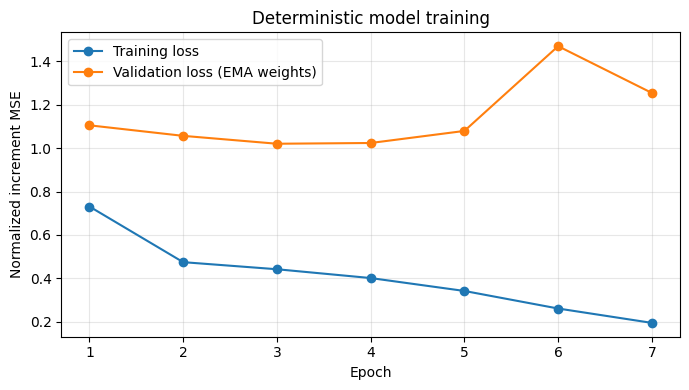

Best deterministic epoch: 3 | val loss: 1.0204275473058224


In [16]:
det_history = fit(det_model, deterministic_loss, "deterministic_v2", train_loader, valid_loader,
                  training_stats, EPOCHS, LEARNING_RATE, weight_decay=WEIGHT_DECAY, patience=PATIENCE)

plot_history(det_history, "Deterministic model training", "Normalized increment MSE")
det_checkpoint, det_stats = load_checkpoint(det_model, "best_deterministic_v2.pt")

print("Best deterministic epoch:", det_checkpoint["epoch"], "| val loss:", det_checkpoint["val_loss"])

flow_matching_v2 train:   0%|          | 0/2500 [00:00<?, ?it/s]

flow_matching_v2 valid:   0%|          | 0/125 [00:00<?, ?it/s]

[flow_matching_v2] epoch 01/20 | train 0.7723 | val (EMA) 0.5777


flow_matching_v2 train:   0%|          | 0/2500 [00:00<?, ?it/s]

flow_matching_v2 valid:   0%|          | 0/125 [00:00<?, ?it/s]

...

flow_matching_v2 valid:   0%|          | 0/125 [00:00<?, ?it/s]

[flow_matching_v2] epoch 19/20 | train 0.1298 | val (EMA) 0.2023


flow_matching_v2 train:   0%|          | 0/2500 [00:00<?, ?it/s]

flow_matching_v2 valid:   0%|          | 0/125 [00:00<?, ?it/s]

[flow_matching_v2] epoch 20/20 | train 0.1286 | val (EMA) 0.2016


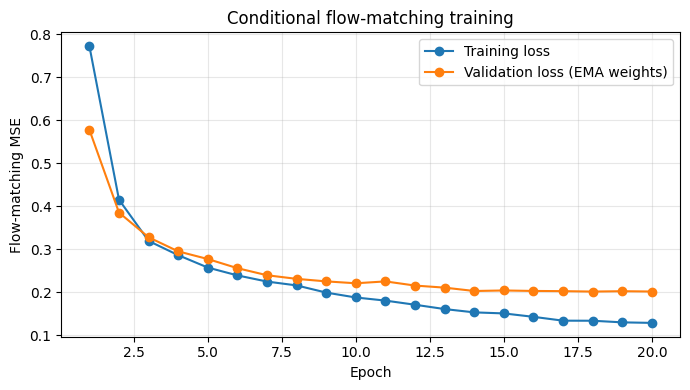

Best flow-matching epoch: 18 | val loss: 0.2014565364215523


'/content/drive/MyDrive/ML for science/best_flow_matching_v2.pt'

In [17]:
#######
# Train the conditional flow-matching model
import shutil
SAVE_DIR = "/content/drive/MyDrive/ML for science"

# Back up the trained deterministic checkpoint to Google Drive
shutil.copy2("best_deterministic_v2.pt", f"{SAVE_DIR}/best_deterministic_v2.pt")
fm_history = fit(fm_model, flow_matching_loss, "flow_matching_v2", train_loader, valid_loader,
                 training_stats, EPOCHS, LEARNING_RATE, weight_decay=WEIGHT_DECAY, patience=PATIENCE)

plot_history(fm_history, "Conditional flow-matching training", "Flow-matching MSE")
fm_checkpoint, fm_stats = load_checkpoint(fm_model, "best_flow_matching_v2.pt")
print("Best flow-matching epoch:", fm_checkpoint["epoch"], "| val loss:", fm_checkpoint["val_loss"])
shutil.copy2("best_flow_matching_v2.pt", f"{SAVE_DIR}/best_flow_matching_v2.pt")

In [18]:
#######
# Load the trained models from Google Drive
# (safe to run after normal training; also used to restore after a Colab disconnect)
SAVE_DIR = "/content/drive/MyDrive/ML for science"
det_checkpoint, det_stats = load_checkpoint(det_model, f"{SAVE_DIR}/best_deterministic_v2.pt")
fm_checkpoint, fm_stats = load_checkpoint(fm_model, f"{SAVE_DIR}/best_flow_matching_v2.pt")
print("Deterministic: epoch", det_checkpoint["epoch"], "| val loss", det_checkpoint["val_loss"])
print("Flow matching: epoch", fm_checkpoint["epoch"], "| val loss", fm_checkpoint["val_loss"])

Deterministic: epoch 3 | val loss 1.0204275473058224
Flow matching: epoch 18 | val loss 0.2014565364215523


# 7. Final evaluation: wake temporal activity

The supplied evaluation code computes how strongly the velocity field changes over a finite time interval in a fixed downstream wake region. The following sections explain the metric and protocol implemented below. **Your task is to connect your trained models through the two adapter functions, run the provided evaluation and plotting functions, and interpret the results alongside rollout visualizations**.

For two states at times $t_0$ and $t_1$, define at each mesh node $i$,
$
a_i(t_0,t_1)=
\frac{
\left\|
\mathbf u_i(t_1)-\mathbf u_i(t_0)
\right\|_2
}{
t_1-t_0
}.
$

This uses the full velocity vector, so changes in both velocity magnitude and direction contribute.

For a triangle $K$ with nodes $i,j,k$, the nodal scalar $a$ is linearly interpolated over the triangle. Its triangle-average value is therefore
$
a_K=
\frac{a_i+a_j+a_k}{3}.
$

For all triangles whose centroids lie inside the fixed wake region, define the area-weighted temporal activity
$
D_{\mathrm{wake}}(t_0,t_1)=
\frac{
\sum_{K\in\mathrm{wake}} A_K\,a_K
}{
\sum_{K\in\mathrm{wake}} A_K
}.
$

### Interpretation

A larger value means that the wake velocity field changes more strongly between the two endpoint states. A smaller value means less finite-time change.

The first rollout interval $0\rightarrow1\,\mathrm{s}$ is treated as a burn-in interval and is not used to calculate the metric. The reported metric begins with the interval $1\rightarrow2\,\mathrm{s}$.


## 8. Wake region used by the metric

The provided metric function uses a fixed physical rectangle downstream of the cylinder:

$
0.55\le x\le1.55,
\qquad
0.03\le y\le0.39.
$

A triangle contributes if its centroid lies inside this rectangle. The same region is used for ground truth, the deterministic model, and every generative sample.

The area weighting is important because the mesh is nonuniform: a large triangle represents more physical area than a small triangle.

The region is fixed in advance and must not be tuned separately for different models.


In [19]:
# ============================================================
# Fixed wake region and absolute temporal-activity metric
# ============================================================

METRIC_WAKE_X_MIN = 0.55
METRIC_WAKE_X_MAX = 1.55
METRIC_WAKE_Y_MIN = 0.03
METRIC_WAKE_Y_MAX = 0.39


def triangle_areas_and_centroids(mesh_pos, cells):
    if torch.is_tensor(mesh_pos):
        mesh_pos = mesh_pos.detach().cpu().numpy()

    if torch.is_tensor(cells):
        cells = cells.detach().cpu().numpy()

    pos = np.asarray(mesh_pos, dtype=np.float64)
    cells = np.asarray(cells, dtype=np.int64)

    p0 = pos[cells[:, 0]]
    p1 = pos[cells[:, 1]]
    p2 = pos[cells[:, 2]]

    cross = (
        (p1[:, 0] - p0[:, 0])
        *
        (p2[:, 1] - p0[:, 1])
        -
        (p1[:, 1] - p0[:, 1])
        *
        (p2[:, 0] - p0[:, 0])
    )

    areas = 0.5 * np.abs(cross)
    centroids = (p0 + p1 + p2) / 3.0

    return areas, centroids


def wake_triangle_mask(centroids):
    x = centroids[:, 0]
    y = centroids[:, 1]

    return (
        (x >= METRIC_WAKE_X_MIN)
        &
        (x <= METRIC_WAKE_X_MAX)
        &
        (y >= METRIC_WAKE_Y_MIN)
        &
        (y <= METRIC_WAKE_Y_MAX)
    )


def wake_velocity_temporal_activity(
    mesh_pos,
    cells,
    velocity_start,
    velocity_end,
    delta_t,
):
    """
    Area-weighted wake average of

        ||u(t1) - u(t0)||_2 / (t1 - t0)

    using the full velocity vector.
    """

    if delta_t <= 0:
        raise ValueError("delta_t must be positive.")

    if torch.is_tensor(velocity_start):
        velocity_start = velocity_start.detach().cpu().numpy()

    if torch.is_tensor(velocity_end):
        velocity_end = velocity_end.detach().cpu().numpy()

    cells_np = (
        cells.detach().cpu().numpy()
        if torch.is_tensor(cells)
        else np.asarray(cells)
    ).astype(np.int64)

    v0 = np.asarray(velocity_start, dtype=np.float64)
    v1 = np.asarray(velocity_end, dtype=np.float64)

    # Full-vector finite-time change rate at each node.
    node_activity = (
        np.linalg.norm(
            v1 - v0,
            axis=-1,
        )
        /
        float(delta_t)
    )

    areas, centroids = triangle_areas_and_centroids(
        mesh_pos,
        cells_np,
    )

    wake = wake_triangle_mask(centroids)

    if not np.any(wake):
        raise RuntimeError(
            "No mesh triangles fall inside the fixed wake region."
        )

    # Exact triangle mean of the linearly interpolated nodal scalar.
    tri_activity = (
        node_activity[cells_np[:, 0]]
        +
        node_activity[cells_np[:, 1]]
        +
        node_activity[cells_np[:, 2]]
    ) / 3.0

    return float(
        np.sum(
            areas[wake]
            *
            tri_activity[wake]
        )
        /
        np.sum(areas[wake])
    )


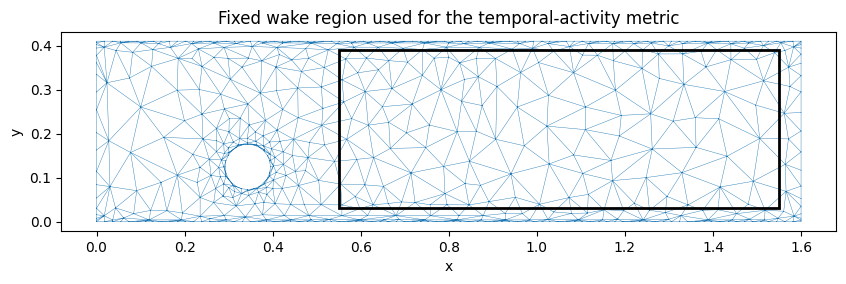

In [20]:
# Visualize the fixed evaluation region on the example mesh.
from matplotlib.patches import Rectangle

example_pos = example["mesh_pos"].numpy()
example_cells = example["cells"].numpy()

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.triplot(example_pos[:, 0], example_pos[:, 1], example_cells, linewidth=0.3)

rect = Rectangle(
    (METRIC_WAKE_X_MIN, METRIC_WAKE_Y_MIN),
    METRIC_WAKE_X_MAX - METRIC_WAKE_X_MIN,
    METRIC_WAKE_Y_MAX - METRIC_WAKE_Y_MIN,
    fill=False,
    linewidth=2,
)
ax.add_patch(rect)
ax.set_title("Fixed wake region used for the temporal-activity metric")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
plt.show()

## 10. Rollout evaluation protocol

The provided evaluation code implements the following protocol for the final comparison. Run it after implementing the two model adapter functions below:

- The evaluator uses **20 held-out test trajectories**;
- Every rollout starts from the same ground-truth state at $t=0$;
- Each model step advances the model by **1 second**;
- The rollout code generates model states at nominal times $t=0,1,2,3,4,5,6\,\mathrm{s}$;
- The evaluator automatically excludes $0\rightarrow1\,\mathrm{s}$ from the metric as burn-in; students do not need to implement this exclusion;
- The evaluator calculates the metric on the intervals
  $
  1\rightarrow2,\quad
  2\rightarrow3,\quad
  3\rightarrow4,\quad
  4\rightarrow5,\quad
  5\rightarrow6\,\mathrm{s};
  $
- The evaluator runs **5 flow-matching rollouts per test trajectory** with distinct random seeds by repeatedly calling your `generative_next_velocity` adapter. You must implement the conditional sampling procedure, including noise generation using the supplied random generator and numerical integration of the learned flow-matching ODE;
- The evaluator computes the absolute temporal-activity value separately for every generative rollout;
- The supplied aggregation function averages the 5 generative activity values within each trajectory/interval first, then summarizes across trajectories.

### Final ground-truth endpoint

The stored trajectory ends at $5.99\,\mathrm{s}$, not exactly $6.00\,\mathrm{s}$. Therefore, for the final displayed interval:

- deterministic and flow-matching rollouts use their nominal $5.00\rightarrow6.00\,\mathrm{s}$ states and divide by $1.00\,\mathrm{s}$;
- ground truth uses the available $5.00\rightarrow5.99\,\mathrm{s}$ states and divides by the actual $0.99\,\mathrm{s}$.

The final GT point is therefore a $0.99\,\mathrm{s}$ reference for the nominal 6-second endpoint.

This metric measures **finite-time temporal activity**, not pointwise prediction accuracy and not the spatial location or phase of individual vortices. Use it together with rollout visualizations.


In [21]:
def load_full_trajectory(h5_path, split, traj_id):
    """Load one full trajectory into CPU torch tensors."""
    with h5py.File(h5_path, "r") as f:
        g = f[split][traj_id]
        return {
            "trajectory_id": traj_id,
            "mesh_pos": torch.from_numpy(g["mesh_pos"][:]).float(),
            "cells": torch.from_numpy(g["cells"][:].astype(np.int64)).long(),
            "node_type": torch.from_numpy(g["node_type"][:].astype(np.int64)).long(),
            "velocity": torch.from_numpy(g["velocity"][:]).float(),
        }


def test_trajectory_ids(h5_path):
    with h5py.File(h5_path, "r") as f:
        return sorted(f["test"].keys())

### Connect your trained models to the evaluator

Implement the two adapter functions below to connect your trained models to the supplied evaluator. The deterministic adapter must call your trained predictor. The generative adapter must implement or call your flow-matching sampler, including Gaussian noise generation and numerical integration of the learned ODE; this sampling code is not supplied. The metric, boundary enforcement, autoregressive rollout loops, evaluation protocol, aggregation, and metric plotting are already implemented in the following code cells.

Each function must return the **full physical velocity field one second later**, with shape `(N, 2)`. If your model works with normalized velocities or normalized increments internally, perform the required denormalization inside the adapter before returning.

The evaluation code does not assume any particular neural-network architecture.

`generative_next_velocity` should produce a new conditional sample when the supplied random generator changes. After implementing both adapters, run the example calls provided at the ends of the evaluation and aggregation cells with your trained models to compute, summarize, and plot the results. Interpret the comparison using the metric definition and rollout visualizations.


In [22]:
# Flow-matching sampling configuration
FM_ODE_STEPS = 10

def _graph_tensors(trajectory, device):
    if "_edge_index" not in trajectory:
        trajectory["_edge_index"] = cells_to_edges(trajectory["cells"]).to(device)
        trajectory["_graph_index"] = torch.zeros(
            trajectory["mesh_pos"].shape[0], dtype=torch.long, device=device)
    return trajectory["_edge_index"], trajectory["_graph_index"]

@torch.no_grad()
def deterministic_next_velocity(model, trajectory, current_velocity):
    """
    TODO: predict the full velocity field one physical second ahead.

    Parameters
    ----------
    model : trained model
        Your model, placed on DEVICE and set to evaluation mode before rollout.
    trajectory : dict[str, torch.Tensor]
        Static mesh information for one trajectory (no batch dimension):
        - mesh_pos: float32 tensor, shape (N, 2), containing node (x, y) coordinates.
        - cells: int64 tensor, shape (M, 3), containing triangle node indices.
        - node_type: int64 tensor, shape (N,), containing labels 0 (interior),
          4 (inflow), 5 (outflow), or 6 (wall).
        All tensors are on DEVICE. N is the number of nodes and M is the number
        of triangles; both can vary between trajectories. This dictionary does
        not contain velocity history or future ground-truth states.
    current_velocity : torch.Tensor
        Float32 tensor of shape (N, 2) on DEVICE, in physical, unnormalized
        units. Columns contain (u_x, u_y). This is the ground-truth initial
        state for the first step and the previous prediction for later steps.

    Returns
    -------
    torch.Tensor
        Full velocity field u(t + 1 s), shape (N, 2), on the same device and
        with the same dtype as current_velocity, in physical, unnormalized
        units. If the model predicts a normalized increment, denormalize it
        and add it to current_velocity before returning.

    Notes
    -----
    One call advances physical time by 1 second (100 stored data steps).
    Return values for all N nodes. The supplied rollout code restores the
    known inflow and wall velocities after each call; interior and outflow
    velocities remain predicted.
    Implement model-specific feature preparation, normalization, inference,
    and denormalization here. This adapter returns one deterministic prediction.
    """
    model.eval()
    stats = get_model_stats(model)
    edge_index, graph_index = _graph_tensors(trajectory, current_velocity.device)
    pred = model(current_velocity, trajectory["mesh_pos"], trajectory["node_type"],
                 edge_index, graph_index, 1, stats)
    return current_velocity + denormalize_delta(pred.to(current_velocity.dtype), stats)



@torch.no_grad()
def generative_next_velocity(model, trajectory, current_velocity, generator):
    """
    TODO: sample a full velocity field one physical second ahead.

    Parameters
    ----------
    model : trained model
        Your model, placed on DEVICE and set to evaluation mode before rollout.
    trajectory : dict[str, torch.Tensor]
        Static mesh information for one trajectory (no batch dimension):
        - mesh_pos: float32 tensor, shape (N, 2), containing node (x, y) coordinates.
        - cells: int64 tensor, shape (M, 3), containing triangle node indices.
        - node_type: int64 tensor, shape (N,), containing labels 0 (interior),
          4 (inflow), 5 (outflow), or 6 (wall).
        All tensors are on DEVICE. N is the number of nodes and M is the number
        of triangles; both can vary between trajectories. This dictionary does
        not contain velocity history or future ground-truth states.
    current_velocity : torch.Tensor
        Float32 tensor of shape (N, 2) on DEVICE, in physical, unnormalized
        units. Columns contain (u_x, u_y). This is the ground-truth initial
        state for the first step and the previous prediction for later steps.
    generator : torch.Generator
        Random generator on DEVICE, seeded by the supplied rollout code.
        Use it for all sampling randomness, for example:
        torch.randn(current_velocity.shape, device=current_velocity.device,
                    dtype=current_velocity.dtype, generator=generator).
        Do not reset its seed inside this function. Its state advances across
        rollout steps, and separate rollouts receive distinct seeds.

    Returns
    -------
    torch.Tensor
        Full velocity field u(t + 1 s), shape (N, 2), on the same device and
        with the same dtype as current_velocity, in physical, unnormalized
        units. If the model predicts a normalized increment, denormalize it
        and add it to current_velocity before returning.

    Notes
    -----
    One call advances physical time by 1 second (100 stored data steps).
    Return values for all N nodes. The supplied rollout code restores the
    known inflow and wall velocities after each call; interior and outflow
    velocities remain predicted.
    Implement or call your conditional flow-matching sampler here: draw fresh
    Gaussian noise, integrate the learned vector field over flow time tau from
    0 to 1 conditioned on current_velocity and the mesh, and convert the sample
    to a physical velocity field. Flow time tau is separate from physical time.
    Noise generation and ODE integration are student tasks, not supplied by
    the evaluator. Return one sample per call, not an ensemble or sample mean.
    """

    model.eval()
    stats = get_model_stats(model)
    edge_index, graph_index = _graph_tensors(trajectory, current_velocity.device)
    boundary = boundary_node_mask(trajectory["node_type"])[:, None]

    def vector_field(z, t):
        tau = torch.full((1,), t, device=z.device, dtype=z.dtype)
        v = model(current_velocity, trajectory["mesh_pos"], trajectory["node_type"],
                  edge_index, graph_index, 1, stats, z_tau=z, tau=tau)
        return v.to(z.dtype).masked_fill(boundary, 0.0)

    # fresh noise from the supplied generator (never reseeded here)
    z = torch.randn(current_velocity.shape, device=current_velocity.device,
                    dtype=current_velocity.dtype, generator=generator).masked_fill(boundary, 0.0)

    h = 1.0 / FM_ODE_STEPS
    for k in range(FM_ODE_STEPS):
        t = k * h
        v1 = vector_field(z, t)
        v2 = vector_field(z + h * v1, t + h)
        z = z + 0.5 * h * (v1 + v2)

    return current_velocity + denormalize_delta(z, stats)

In [23]:
def enforce_known_boundaries(next_velocity, current_velocity, node_type):
    """Keep inflow/wall nodes fixed; interior and outflow nodes remain predicted."""
    out = next_velocity.clone()
    dynamic = dynamic_node_mask(node_type)
    out[~dynamic] = current_velocity[~dynamic]
    return out


@torch.no_grad()
def rollout_deterministic_generic(model, trajectory, n_steps=5):
    current = trajectory["velocity"][0].to(DEVICE)
    tr_static = {
        "mesh_pos": trajectory["mesh_pos"].to(DEVICE),
        "cells": trajectory["cells"].to(DEVICE),
        "node_type": trajectory["node_type"].to(DEVICE),
    }

    states = [current.detach().cpu()]
    for _ in range(n_steps):
        nxt = deterministic_next_velocity(model, tr_static, current)
        nxt = enforce_known_boundaries(nxt, current, tr_static["node_type"])
        current = nxt
        states.append(current.detach().cpu())

    return torch.stack(states)


@torch.no_grad()
def rollout_generative_generic(model, trajectory, n_steps=5, seed=0):
    current = trajectory["velocity"][0].to(DEVICE)
    tr_static = {
        "mesh_pos": trajectory["mesh_pos"].to(DEVICE),
        "cells": trajectory["cells"].to(DEVICE),
        "node_type": trajectory["node_type"].to(DEVICE),
    }

    gen = torch.Generator(device=DEVICE)
    gen.manual_seed(int(seed))

    states = [current.detach().cpu()]
    for _ in range(n_steps):
        nxt = generative_next_velocity(model, tr_static, current, gen)
        nxt = enforce_known_boundaries(nxt, current, tr_static["node_type"])
        current = nxt
        states.append(current.detach().cpu())

    return torch.stack(states)

In [24]:
# ============================================================
# Final rollout temporal-activity evaluation
# ============================================================

N_EVAL_TRAJ = 20
N_GENERATIVE_SAMPLES = 5

# Six 1-second model steps are needed to form the final scored
# interval 5 -> 6 s.
N_MODEL_ROLLOUT_STEPS = 6

# The first interval 0 -> 1 s is burn-in.
BURN_IN_STEPS = 1

EVAL_SEED = 1234


@torch.no_grad()
def evaluate_rollout_temporal_activity(
    det_model,
    generative_model,
):
    rows = []

    ids = test_trajectory_ids(DATA_PATH)[:N_EVAL_TRAJ]

    for traj_number, traj_id in enumerate(
        tqdm(
            ids,
            desc="Test trajectories",
        )
    ):
        tr = load_full_trajectory(
            DATA_PATH,
            "test",
            traj_id,
        )

        # ----------------------------------------------------
        # Generate model rollouts to nominal t = 6 s.
        # ----------------------------------------------------

        det = rollout_deterministic_generic(
            det_model,
            tr,
            n_steps=N_MODEL_ROLLOUT_STEPS,
        )

        fm_rollouts = []

        for sample_id in tqdm(
            range(N_GENERATIVE_SAMPLES),
            desc=f"Generative samples {traj_id}",
            leave=False,
        ):
            seed = (
                EVAL_SEED
                +
                1000 * traj_number
                +
                sample_id
            )

            fm_rollouts.append(
                rollout_generative_generic(
                    generative_model,
                    tr,
                    n_steps=N_MODEL_ROLLOUT_STEPS,
                    seed=seed,
                )
            )

        # ----------------------------------------------------
        # Score intervals:
        #
        #   1 -> 2
        #   2 -> 3
        #   3 -> 4
        #   4 -> 5
        #   5 -> 6 nominally
        #
        # 0 -> 1 is burn-in and is not scored.
        # ----------------------------------------------------

        T = tr["velocity"].shape[0]

        for end_step in range(
            BURN_IN_STEPS + 1,
            N_MODEL_ROLLOUT_STEPS + 1,
        ):
            start_step = end_step - 1

            nominal_start_s = (
                start_step
                *
                PREDICTION_DT
            )

            nominal_end_s = (
                end_step
                *
                PREDICTION_DT
            )

            # ------------------------------------------------
            # Ground-truth endpoints.
            #
            # For 1->2, ..., 4->5, exact 1-second endpoints
            # exist in the stored trajectory.
            #
            # For the final nominal 5->6 interval, use
            # 5.00 -> 5.99 s.
            # ------------------------------------------------

            gt_start_idx = (
                start_step
                *
                HORIZON_STEPS
            )

            desired_gt_end_idx = (
                end_step
                *
                HORIZON_STEPS
            )

            gt_end_idx = min(
                desired_gt_end_idx,
                T - 1,
            )

            gt_start_time_s = (
                gt_start_idx
                *
                DT
            )

            gt_end_time_s = (
                gt_end_idx
                *
                DT
            )

            gt_delta_t = (
                gt_end_time_s
                -
                gt_start_time_s
            )

            if gt_delta_t <= 0:
                continue

            gt_activity = (
                wake_velocity_temporal_activity(
                    tr["mesh_pos"],
                    tr["cells"],
                    tr["velocity"][gt_start_idx],
                    tr["velocity"][gt_end_idx],
                    gt_delta_t,
                )
            )

            rows.append({
                "trajectory": traj_id,
                "interval_start_s": nominal_start_s,
                "interval_end_s": nominal_end_s,
                "gt_interval_end_s": gt_end_time_s,
                "model": "Ground truth",
                "sample": -1,
                "temporal_activity": gt_activity,
            })

            # ------------------------------------------------
            # Deterministic model:
            # always a nominal 1-second model interval.
            # ------------------------------------------------

            det_activity = (
                wake_velocity_temporal_activity(
                    tr["mesh_pos"],
                    tr["cells"],
                    det[start_step],
                    det[end_step],
                    PREDICTION_DT,
                )
            )

            rows.append({
                "trajectory": traj_id,
                "interval_start_s": nominal_start_s,
                "interval_end_s": nominal_end_s,
                "gt_interval_end_s": gt_end_time_s,
                "model": "Deterministic",
                "sample": -1,
                "temporal_activity": det_activity,
            })

            # ------------------------------------------------
            # Flow matching: evaluate every sampled rollout.
            # ------------------------------------------------

            for sample_id, fm in enumerate(
                fm_rollouts
            ):
                fm_activity = (
                    wake_velocity_temporal_activity(
                        tr["mesh_pos"],
                        tr["cells"],
                        fm[start_step],
                        fm[end_step],
                        PREDICTION_DT,
                    )
                )

                rows.append({
                    "trajectory": traj_id,
                    "interval_start_s": nominal_start_s,
                    "interval_end_s": nominal_end_s,
                    "gt_interval_end_s": gt_end_time_s,
                    "model": "Flow matching",
                    "sample": sample_id,
                    "temporal_activity": fm_activity,
                })

    return pd.DataFrame(rows)


# Run after implementing the two model adapter functions above:
#
rollout_activity_raw = evaluate_rollout_temporal_activity(
    det_model,
    fm_model
)

print("Evaluation rows:", len(rollout_activity_raw))
display(rollout_activity_raw.head())

Test trajectories:   0%|          | 0/20 [00:00<?, ?it/s]

Generative samples traj_0000:   0%|          | 0/5 [00:00<?, ?it/s]

Generative samples traj_0001:   0%|          | 0/5 [00:00<?, ?it/s]

Generative samples traj_0002:   0%|          | 0/5 [00:00<?, ?it/s]

Generative samples traj_0003:   0%|          | 0/5 [00:00<?, ?it/s]

...

Generative samples traj_0017:   0%|          | 0/5 [00:00<?, ?it/s]

Generative samples traj_0018:   0%|          | 0/5 [00:00<?, ?it/s]

Generative samples traj_0019:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluation rows: 700


,trajectory,interval_start_s,interval_end_s,gt_interval_end_s,model,sample,temporal_activity
0,traj_0000,1.0,2.0,2.0,Ground truth,-1,0.195066
1,traj_0000,1.0,2.0,2.0,Deterministic,-1,0.043674
2,traj_0000,1.0,2.0,2.0,Flow matching,0,0.127804
3,traj_0000,1.0,2.0,2.0,Flow matching,1,0.161200
4,traj_0000,1.0,2.0,2.0,Flow matching,2,0.251114


,model,interval_start_s,interval_end_s,mean_activity,std_activity,median_activity,n_trajectories
0,Deterministic,1.0,2.0,0.069901,0.033821,0.062035,20
1,Deterministic,2.0,3.0,0.018431,0.009049,0.016767,20
2,Deterministic,3.0,4.0,0.010543,0.004753,0.009830,20
3,Deterministic,4.0,5.0,0.007829,0.003866,0.007246,20
4,Deterministic,5.0,6.0,0.006375,0.003422,0.005742,20
5,Flow matching,1.0,2.0,0.143757,0.081220,0.139450,20
6,Flow matching,2.0,3.0,0.092363,0.063646,0.085857,20
7,Flow matching,3.0,4.0,0.089553,0.077903,0.066032,20
8,Flow matching,4.0,5.0,0.082358,0.070795,0.066867,20
9,Flow matching,5.0,6.0,0.090840,0.075466,0.081889,20


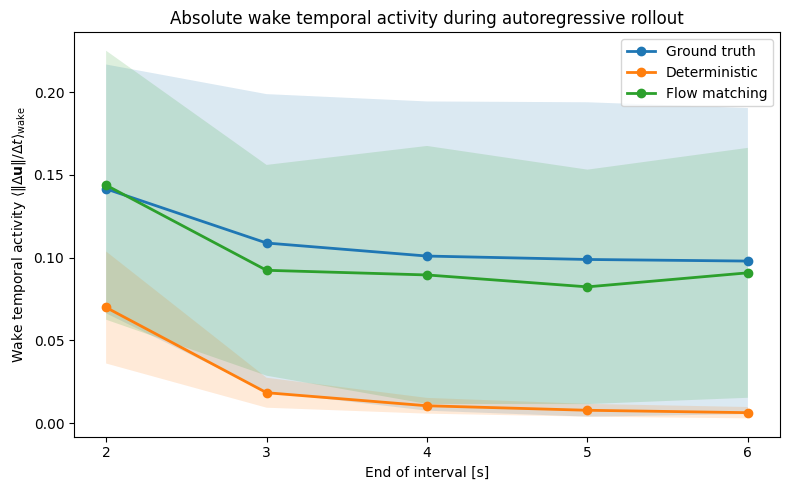

In [25]:
# ============================================================
# Aggregate correctly and plot the metric
# ============================================================

def summarize_rollout_temporal_activity(
    rollout_activity_raw,
):
    # --------------------------------------------------------
    # First average independent FM samples within the same
    # trajectory and interval.
    #
    # GT and deterministic each already have one value.
    # --------------------------------------------------------

    per_condition = (
        rollout_activity_raw
        .groupby(
            [
                "model",
                "trajectory",
                "interval_start_s",
                "interval_end_s",
            ]
        )["temporal_activity"]
        .mean()
        .reset_index()
    )

    # --------------------------------------------------------
    # Then summarize across independent test trajectories.
    # --------------------------------------------------------

    by_time = (
        per_condition
        .groupby(
            [
                "model",
                "interval_start_s",
                "interval_end_s",
            ]
        )
        .agg(
            mean_activity=(
                "temporal_activity",
                "mean",
            ),
            std_activity=(
                "temporal_activity",
                "std",
            ),
            median_activity=(
                "temporal_activity",
                "median",
            ),
            n_trajectories=(
                "trajectory",
                "nunique",
            ),
        )
        .reset_index()
    )

    return (
        per_condition,
        by_time,
    )


def plot_rollout_temporal_activity(
    by_time,
    show_std=True,
):
    plt.figure(
        figsize=(8, 5)
    )

    for model_name in [
        "Ground truth",
        "Deterministic",
        "Flow matching",
    ]:
        d = (
            by_time[
                by_time["model"]
                ==
                model_name
            ]
            .sort_values(
                "interval_end_s"
            )
        )

        plt.plot(
            d["interval_end_s"],
            d["mean_activity"],
            marker="o",
            linewidth=2,
            label=model_name,
        )

        if show_std:
            plt.fill_between(
                d["interval_end_s"],
                d["mean_activity"]
                -
                d["std_activity"],
                d["mean_activity"]
                +
                d["std_activity"],
                alpha=0.16,
            )

    plt.xlabel(
        "End of interval [s]"
    )

    plt.ylabel(
        r"Wake temporal activity "
        r"$\langle \|\Delta\mathbf{u}\|/\Delta t\rangle_{\mathrm{wake}}$"
    )

    plt.title(
        "Absolute wake temporal activity during autoregressive rollout"
    )

    plt.xticks(
        [2, 3, 4, 5, 6]
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


# Example after evaluation:
#
per_condition, by_time = summarize_rollout_temporal_activity(
    rollout_activity_raw
)

display(by_time)
plot_rollout_temporal_activity(by_time,show_std=True)


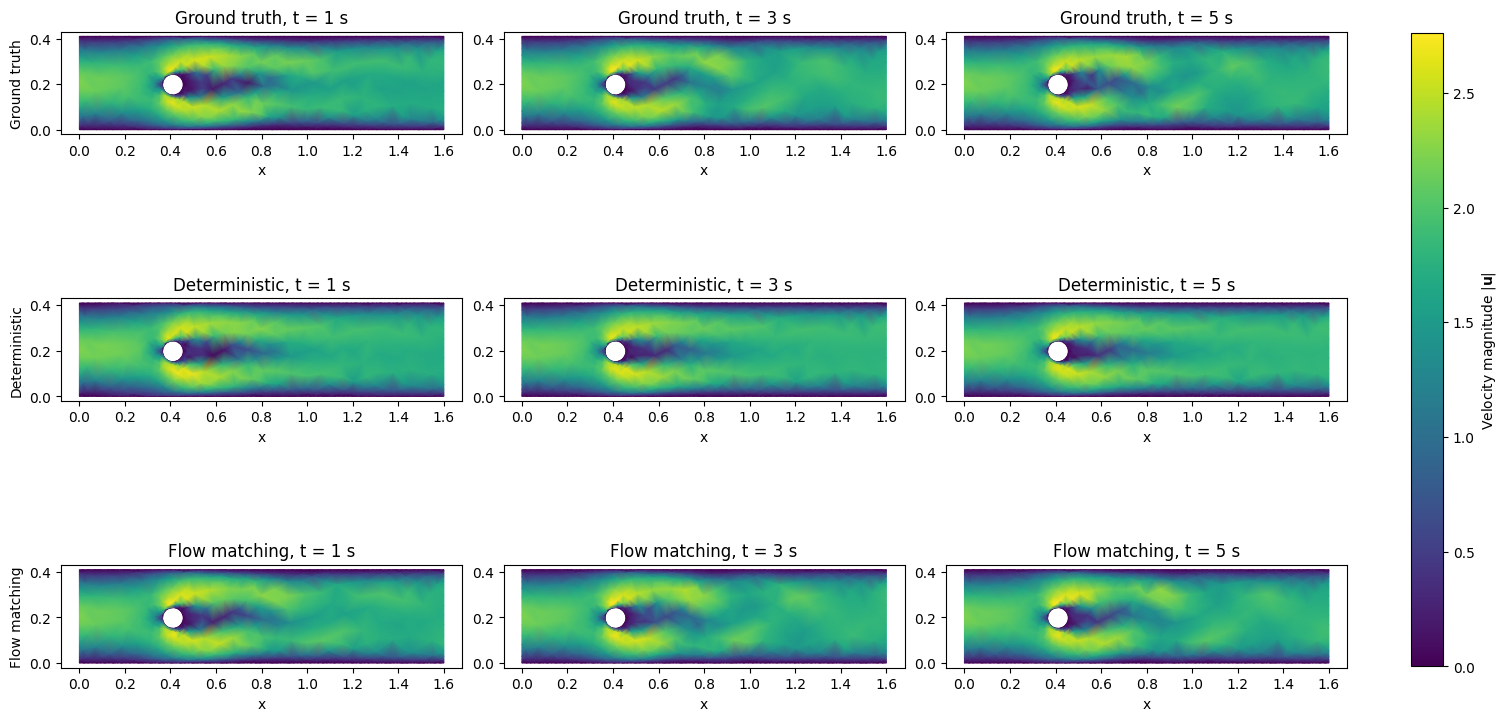

In [26]:
# Visualize one held-out autoregressive rollout

vis_traj_id = test_trajectory_ids(DATA_PATH)[0]
vis_traj = load_full_trajectory(
    DATA_PATH,
    "test",
    vis_traj_id
)

det_rollout = rollout_deterministic_generic(
    det_model,
    vis_traj,
    n_steps=6
)

fm_rollout = rollout_generative_generic(
    fm_model,
    vis_traj,
    n_steps=6,
    seed=EVAL_SEED
)

# Use times with exact ground-truth states.
steps_to_show = [1, 3, 5]

pos = vis_traj["mesh_pos"].numpy()
cells = vis_traj["cells"].numpy()

gt_states = [
    vis_traj["velocity"][step * HORIZON_STEPS]
    for step in steps_to_show
]

all_states = []
for j, step in enumerate(steps_to_show):
    all_states.extend([
        gt_states[j],
        det_rollout[step],
        fm_rollout[step]
    ])

all_speeds = [
    torch.linalg.vector_norm(state, dim=-1).numpy()
    for state in all_states
]

vmin = min(speed.min() for speed in all_speeds)
vmax = max(speed.max() for speed in all_speeds)

fig, axes = plt.subplots(
    3,
    len(steps_to_show),
    figsize=(15, 8),
    constrained_layout=True
)

row_names = [
    "Ground truth",
    "Deterministic",
    "Flow matching"
]

for col, step in enumerate(steps_to_show):
    states = [
        gt_states[col],
        det_rollout[step],
        fm_rollout[step]
    ]

    for row, state in enumerate(states):
        speed = torch.linalg.vector_norm(
            state,
            dim=-1
        ).numpy()

        im = axes[row, col].tripcolor(
            pos[:, 0],
            pos[:, 1],
            cells,
            speed,
            shading="gouraud",
            vmin=vmin,
            vmax=vmax
        )

        axes[row, col].set_aspect("equal")
        axes[row, col].set_title(
            f"{row_names[row]}, t = {step:.0f} s"
        )

        if col == 0:
            axes[row, col].set_ylabel(row_names[row])

        axes[row, col].set_xlabel("x")

cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.8
)
cbar.set_label(r"Velocity magnitude $|\mathbf{u}|$")

plt.show()